In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
import numpy as np


In [2]:
df_quang = pd.read_csv("project-62-at-2026-05-30-15-56-c334f578.csv").reset_index(drop=True)
df_cuong = pd.read_csv("set2_ie403.csv").reset_index(drop=True)
df_duyet = pd.read_csv("set2_Duyet.csv").reset_index(drop=True)

In [3]:
labels_sarcasm = pd.DataFrame({
    'Quang': df_quang['sarcasm'],
    'Cuong': df_cuong['sarcasm'],
    'Duyet': df_duyet['sarcasm']
})

labels_sentiment = pd.DataFrame({
    'Quang': df_quang['sentiment'],
    'Cuong': df_cuong['sentiment'],
    'Duyet': df_duyet['sentiment']
})

In [5]:
pairs = [('Quang', 'Cuong'), ('Quang', 'Duyet'), ('Cuong', 'Duyet')]
print("--- Cohen's Kappa (Độ đồng thuận từng cặp) ---")
for col_name, df_labels in [('Sarcasm', labels_sarcasm), ('Sentiment', labels_sentiment)]:
    print(f"\n{col_name}:")
    for p1, p2 in pairs:
        pair_labels = df_labels[[p1, p2]].dropna()
        score = cohen_kappa_score(pair_labels[p1], pair_labels[p2])
        print(f"  {p1} vs {p2}: {score:.3f}")

--- Cohen's Kappa (Độ đồng thuận từng cặp) ---

Sarcasm:
  Quang vs Cuong: 0.215
  Quang vs Duyet: 0.110
  Cuong vs Duyet: 0.273

Sentiment:
  Quang vs Cuong: 0.565
  Quang vs Duyet: 0.569
  Cuong vs Duyet: 0.709


In [7]:
valid_sarcasm = labels_sarcasm.dropna()
agg_sarcasm, _ = aggregate_raters(valid_sarcasm.values)
kappa_sarcasm = fleiss_kappa(agg_sarcasm, method='fleiss')

valid_sentiment = labels_sentiment.dropna()
agg_sentiment, _ = aggregate_raters(valid_sentiment.values)
kappa_sentiment = fleiss_kappa(agg_sentiment, method='fleiss')

print("\n--- Fleiss' Kappa (Độ đồng thuận 3 người) ---")
print(f"Sarcasm: {kappa_sarcasm:.3f}")
print(f"Sentiment: {kappa_sentiment:.3f}")


--- Fleiss' Kappa (Độ đồng thuận 3 người) ---
Sarcasm: 0.162
Sentiment: 0.605


In [8]:
agree_sarcasm = (labels_sarcasm['Quang'] == labels_sarcasm['Cuong']) & (labels_sarcasm['Cuong'] == labels_sarcasm['Duyet'])
agree_sentiment = (labels_sentiment['Quang'] == labels_sentiment['Cuong']) & (labels_sentiment['Cuong'] == labels_sentiment['Duyet'])

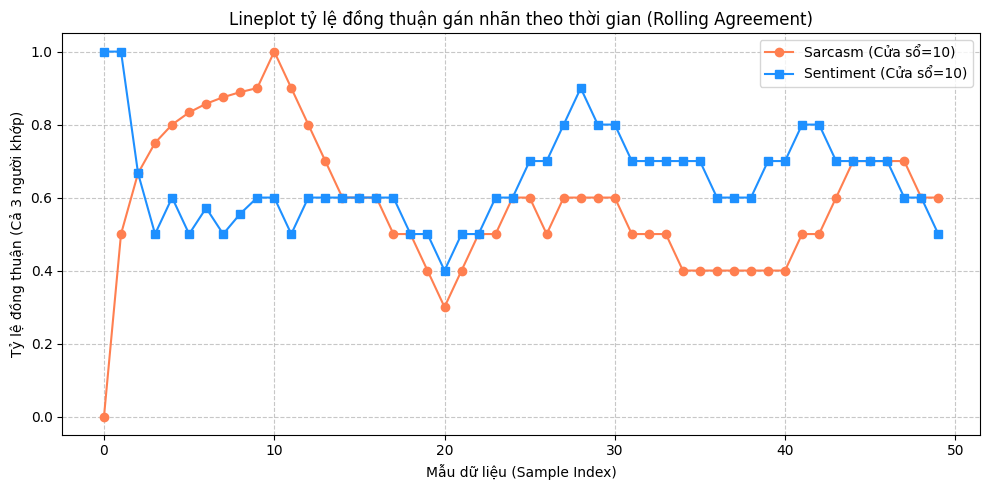

In [9]:

plt.figure(figsize=(10, 5))
agree_sarcasm.rolling(10, min_periods=1).mean().plot(label='Sarcasm (Cửa sổ=10)', marker='o', color='coral')
agree_sentiment.rolling(10, min_periods=1).mean().plot(label='Sentiment (Cửa sổ=10)', marker='s', color='dodgerblue')
plt.title("Lineplot tỷ lệ đồng thuận gán nhãn theo thời gian (Rolling Agreement)")
plt.xlabel("Mẫu dữ liệu (Sample Index)")
plt.ylabel("Tỷ lệ đồng thuận (Cả 3 người khớp)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
def plot_pairwise_agreement(df_labels, title, filename):
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    pairs = [('Quang', 'Cuong'), ('Quang', 'Duyet'), ('Cuong', 'Duyet')]
    
    # Chuyển đổi nhãn văn bản thành số nguyên để mapping lên trục Y
    unique_labels = sorted(df_labels.stack().dropna().unique().tolist())
    label_map = {lbl: i for i, lbl in enumerate(unique_labels)}
    x = np.arange(len(df_labels))
    
    for idx, (p1, p2) in enumerate(pairs):
        ax = axes[idx]
        y1 = df_labels[p1].map(label_map)
        y2 = df_labels[p2].map(label_map)
        
        # Thêm Jitter (độ lệch nhỏ trên trục Y) để các điểm trùng nhau không bị che khuất
        jitter_y1 = y1 + 0.05
        jitter_y2 = y2 - 0.05
        
        ax.scatter(x, jitter_y1, label=p1, marker='o', color='dodgerblue', alpha=0.8, s=40)
        ax.scatter(x, jitter_y2, label=p2, marker='s', color='coral', alpha=0.8, s=40)
        
        # Vẽ đường nối đứt nét tại những mẫu có sự bất đồng
        for i in x:
            if pd.notna(y1[i]) and pd.notna(y2[i]) and y1[i] != y2[i]:
                ax.plot([i, i], [jitter_y1[i], jitter_y2[i]], color='gray', linestyle='--', alpha=0.6)
                
        ax.set_yticks(list(label_map.values()))
        ax.set_yticklabels(list(label_map.keys()))
        ax.set_title(f"So sánh giữa {p1} và {p2}", fontsize=11)
        ax.legend(loc='upper right')
        ax.grid(True, axis='x', linestyle=':', alpha=0.6)
        ax.grid(True, axis='y', linestyle='-', alpha=0.2)
        ax.set_ylim(-0.5, len(unique_labels) - 0.5)
        
    axes[-1].set_xlabel("Thứ tự mẫu dữ liệu (Index)", fontsize=11)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

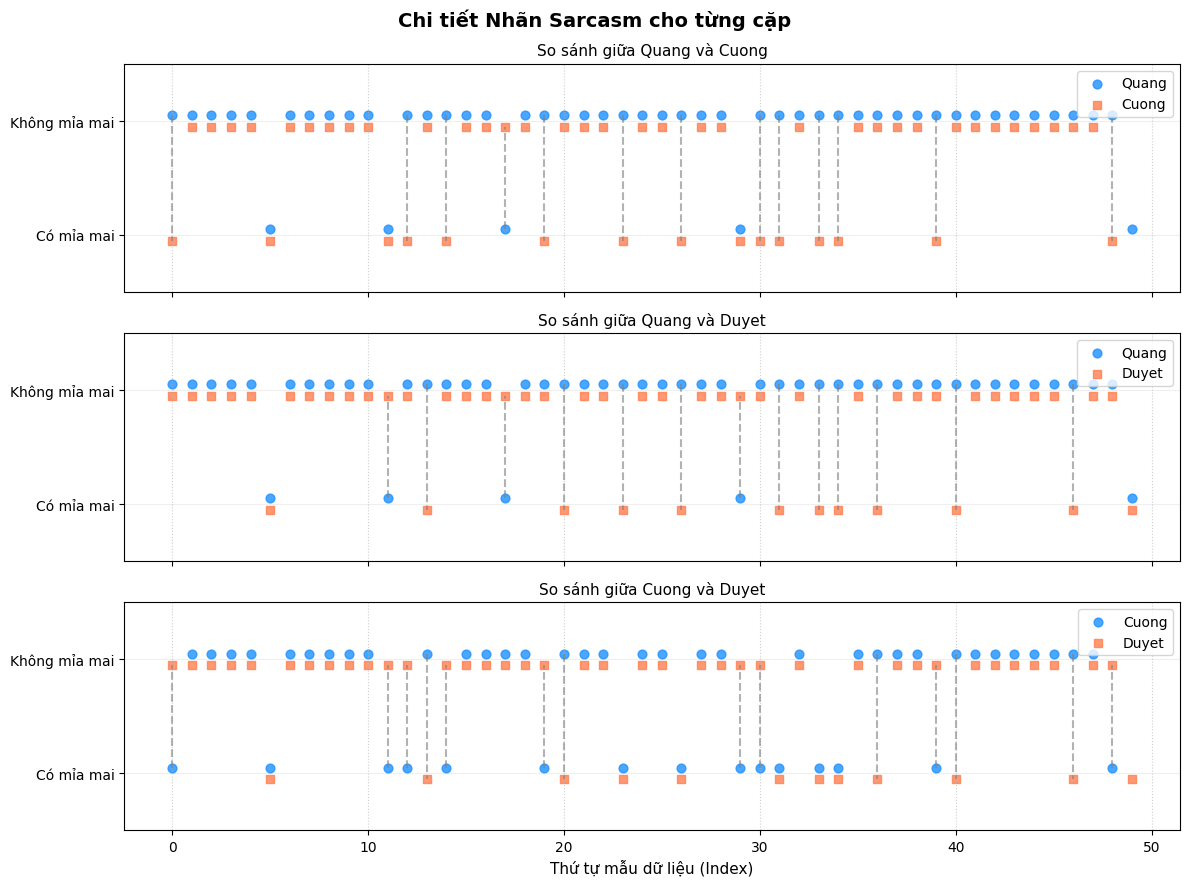

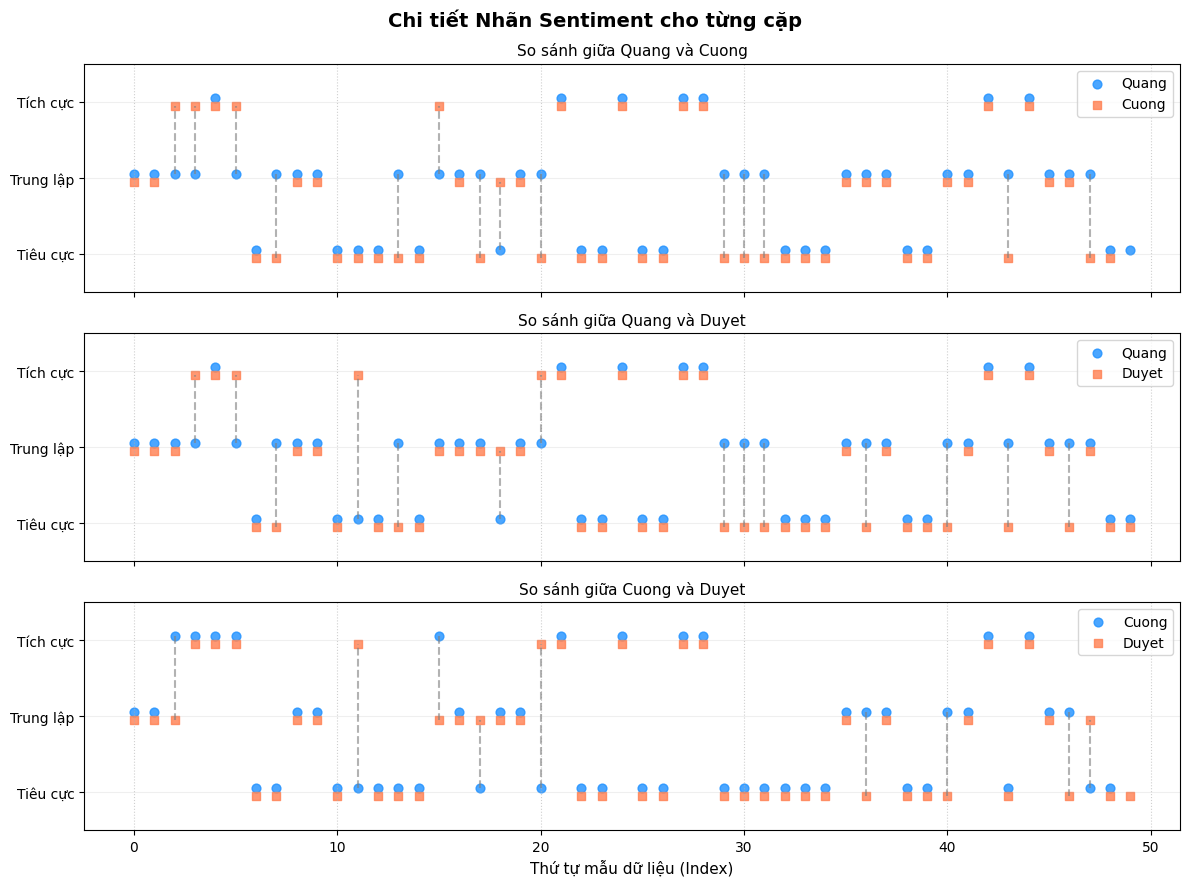

In [11]:
# 3. Chạy hàm để hiển thị Plot
plot_pairwise_agreement(labels_sarcasm, "Chi tiết Nhãn Sarcasm cho từng cặp", "sarcasm_pairwise.png")
plot_pairwise_agreement(labels_sentiment, "Chi tiết Nhãn Sentiment cho từng cặp", "sentiment_pairwise.png")